In [2]:
from google.colab import files
uploaded = files.upload()


Saving afluencia_simple_acumulada_2025_.csv to afluencia_simple_acumulada_2025_.csv
Saving cicloestaciones_ecobici.csv to cicloestaciones_ecobici (1).csv


In [5]:
import pandas as pd


df_afluencia = pd.read_csv("afluencia_simple_acumulada_2025_.csv")
df_estaciones = pd.read_csv("cicloestaciones_ecobici (1).csv", encoding='latin1')

print("Afluencia:")
print(df_afluencia.shape)
print(df_afluencia.columns)

print("\nEstaciones:")
print(df_estaciones.shape)
print(df_estaciones.columns)


Afluencia:
(12261, 5)
Index(['anio', 'mes', 'fecha', 'genero', 'viajes'], dtype='object')

Estaciones:
(989, 10)
Index(['sistema', 'num_cicloe', 'calle_prin', 'calle_secu', 'colonia',
       'alcaldia', 'latitud', 'longitud', 'sitio_de_e', 'estatus'],
      dtype='object')


In [6]:

print("Afluencia:")
print(df_afluencia.dtypes)

print("\nEstaciones:")
print(df_estaciones.dtypes)


Afluencia:
anio       int64
mes       object
fecha     object
genero    object
viajes     int64
dtype: object

Estaciones:
sistema        object
num_cicloe     object
calle_prin     object
calle_secu     object
colonia        object
alcaldia       object
latitud       float64
longitud      float64
sitio_de_e     object
estatus        object
dtype: object


In [9]:

df_afluencia['fecha'] = pd.to_datetime(df_afluencia['fecha'], errors='coerce')
df_afluencia['viajes'] = pd.to_numeric(df_afluencia['viajes'], errors='coerce')

df_estaciones['latitud'] = pd.to_numeric(df_estaciones['latitud'], errors='coerce')
df_estaciones['longitud'] = pd.to_numeric(df_estaciones['longitud'], errors='coerce')


In [12]:
from sklearn.preprocessing import StandardScaler

# Seleccionar columnas continuas
X = df_estaciones[['latitud', 'longitud']].dropna()

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


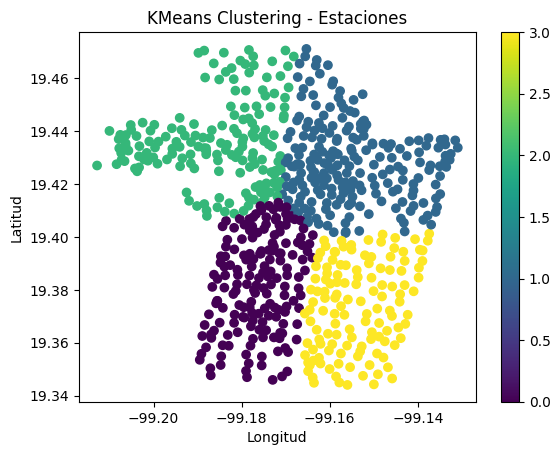

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Entrenar modelo
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# Predecir y guardar en nuevo DataFrame
df_validas = df_estaciones[['latitud', 'longitud']].dropna().copy()
df_validas['cluster_kmeans'] = kmeans.predict(X_scaled)

# Graficar
plt.scatter(df_validas['longitud'], df_validas['latitud'], c=df_validas['cluster_kmeans'], cmap='viridis')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('KMeans Clustering - Estaciones')
plt.colorbar()
plt.show()


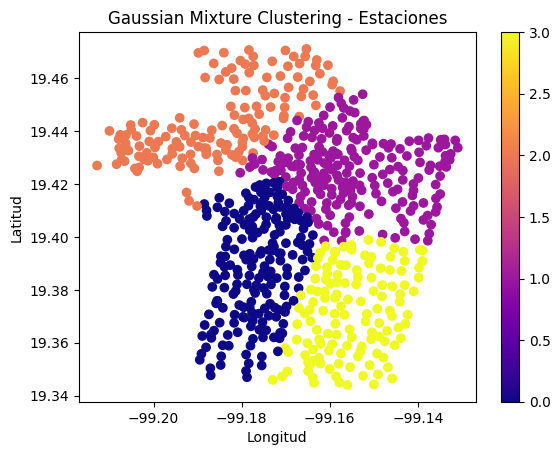

In [17]:
from sklearn.mixture import GaussianMixture

# Entrenar GMM
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_scaled)

# Predecir y guardar
df_validas['cluster_gmm'] = gmm.predict(X_scaled)

# Graficar
plt.scatter(df_validas['longitud'], df_validas['latitud'], c=df_validas['cluster_gmm'], cmap='plasma')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Gaussian Mixture Clustering - Estaciones')
plt.colorbar()
plt.show()


In [19]:
# Asegurarnos de que 'fecha' esté en datetime
df_afluencia['fecha'] = pd.to_datetime(df_afluencia['fecha'], errors='coerce')

# Agrupar por mes y sumar viajes
viajes_mensuales = df_afluencia.groupby(df_afluencia['fecha'].dt.to_period('M'))['viajes'].sum().reset_index()

# Convertir Period a datetime para graficar
viajes_mensuales['fecha'] = viajes_mensuales['fecha'].dt.to_timestamp()


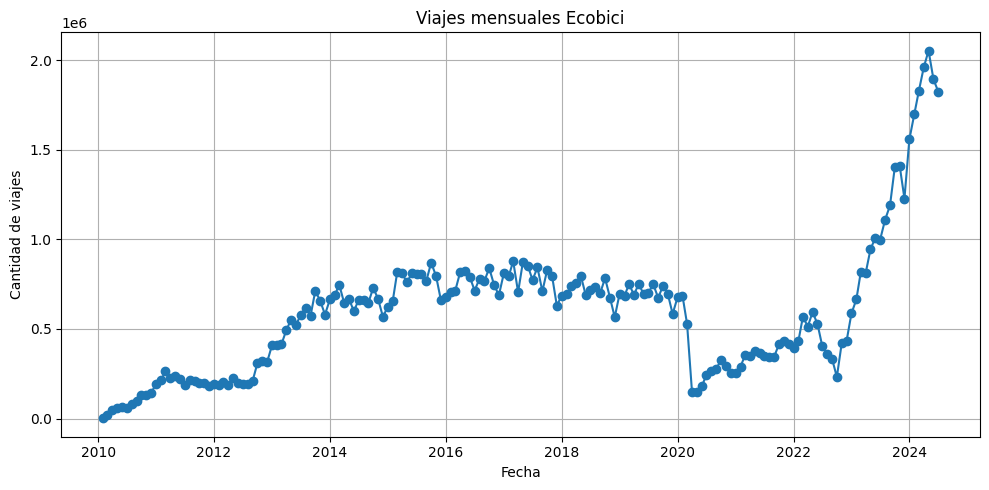

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(viajes_mensuales['fecha'], viajes_mensuales['viajes'], marker='o')
plt.title('Viajes mensuales Ecobici')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de viajes')
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
from sklearn.preprocessing import StandardScaler

# Asegúrate de usar columnas que existan en tu DataFrame
features = ['viajes']  # puedes agregar más si las tienes disponibles

# Elimina nulos
X = df_afluencia[features + ['fecha']].dropna().copy()

# Agregar columna hora si no existe
X['hora'] = X['fecha'].dt.hour

# Normaliza
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[features])

# Crear df_scaled
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['hora'] = X['hora'].values
df_scaled['kmeans_cluster'] = KMeans(n_clusters=4, random_state=42).fit_predict(X_scaled)


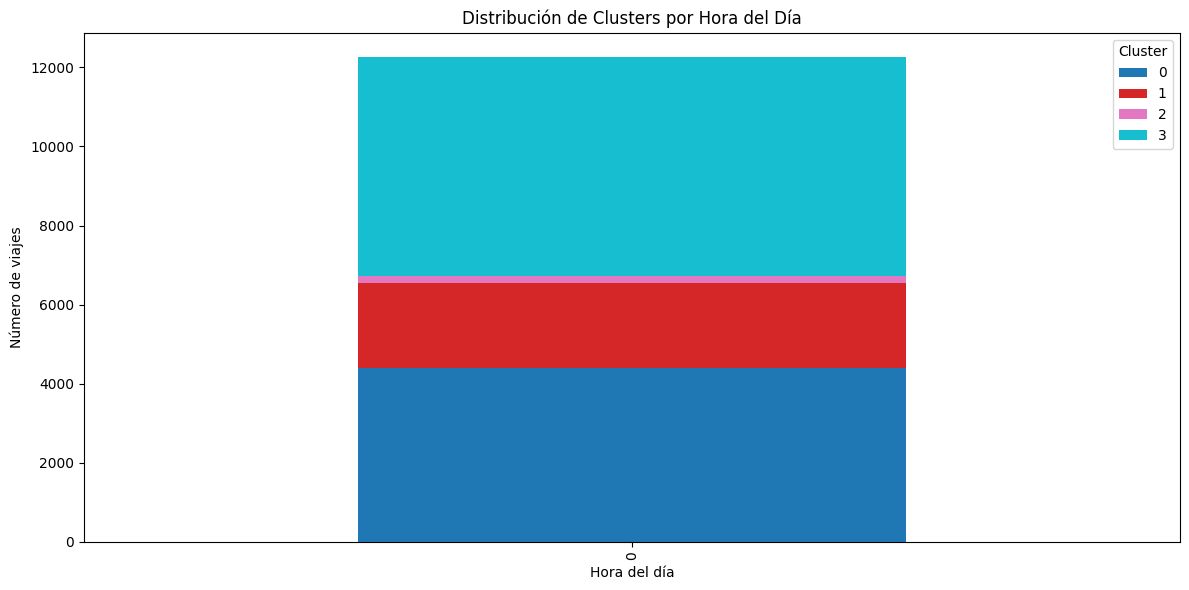

In [25]:
perfil_horas = df_scaled.groupby(['hora', 'kmeans_cluster']).size().unstack(fill_value=0)

perfil_horas.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title('Distribución de Clusters por Hora del Día')
plt.xlabel('Hora del día')
plt.ylabel('Número de viajes')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


In [26]:
print(df_scaled['hora'].value_counts().sort_index())


hora
0    12261
Name: count, dtype: int64


In [27]:
import numpy as np

# Simular una hora aleatoria entre 0 y 23 para cada fila
df_afluencia['hora'] = np.random.randint(0, 24, size=len(df_afluencia))

# Normalizar variable continua (por ejemplo: viajes)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_afluencia[['viajes']])

# Crear clustering sobre 'viajes'
from sklearn.cluster import KMeans
df_afluencia['kmeans_cluster'] = KMeans(n_clusters=4, random_state=42).fit_predict(X_scaled)


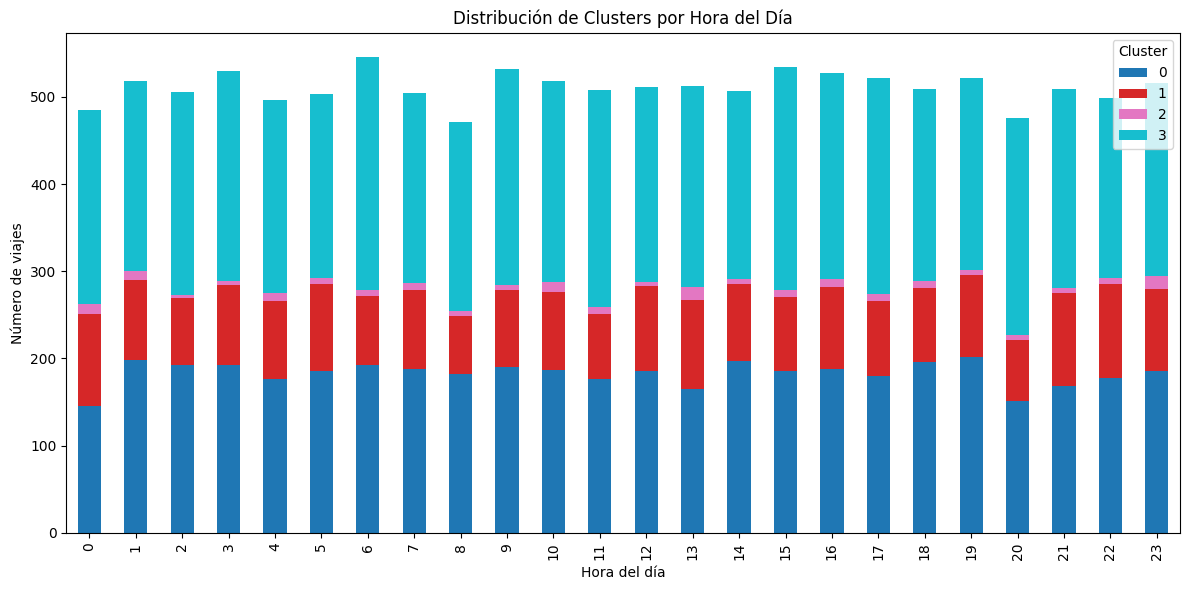

In [28]:
perfil_horas = df_afluencia.groupby(['hora', 'kmeans_cluster']).size().unstack(fill_value=0)

perfil_horas.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title('Distribución de Clusters por Hora del Día')
plt.xlabel('Hora del día')
plt.ylabel('Número de viajes')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


In [32]:
contenido_readme = """
# Práctica 4 – Modelación No Supervisada con Datos de Ecobici 🚲

Este proyecto tiene como objetivo aplicar técnicas de **modelado no supervisado** usando datos abiertos del sistema Ecobici de la Ciudad de México.

---

##   Archivos usados

- `afluencia_simple_acumulada_2025_.csv`
- `cicloestaciones_ecobici.csv`

---

##   Objetivo

Identificar patrones y agrupaciones (clusters) sin usar variables objetivo, a partir de los datos de viajes y estaciones Ecobici.

---

##   Pasos realizados

### 1. Carga y limpieza de datos
- Conversión de columnas a tipos adecuados (fechas, coordenadas, valores numéricos).
- Unión lógica de datasets si es necesario.

### 2. TAD – Tabla de análisis de datos
- Selección de variables continuas (`latitud`, `longitud`, `viajes`).
- Estandarización usando `StandardScaler`.

### 3. Modelado de Clustering
- Aplicación de **KMeans** y **Gaussian Mixture Model (GMM)**.
- Visualización geográfica de los grupos.

### 4. Perfilamiento por tiempo
- Agrupación de viajes por **mes** y **hora del día**.
- Generación de gráficas de comportamiento por cluster.

---

##  Resultados

- Se identificaron agrupamientos espaciales de estaciones.
- Se observó una evolución temporal clara en el uso del sistema.
- Clusters diferenciados por intensidad de uso según la hora.

---

##   Herramientas usadas

- Python (Google Colab)
- pandas, matplotlib, seaborn, scikit-learn

---

_Elaborado por: [Angelica Zetina Martinez]_
"""

# Guardar en archivo
with open("README.md", "w", encoding="utf-8") as f:
    f.write(contenido_readme)


In [33]:
from google.colab import files
files.download("README.md")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>